In [1]:
provider = "aws"
mae = "0.05"
period =  {
    "start": "2024-07-15T00:00:00Z",
    "end": "2024-07-22T00:00:00Z",
    "step": 60
}


In [2]:
carbon_intensity_file = (f"../experiments/in/profiles/{provider}/dynamic/{mae}/{period['start']}-{period['end']}/"+"{}.json").format
stat_file = (f"../experiments/in/profiles/{provider}/static/"+"{}.json").format

In [3]:
regions = ["eu-north-1", "eu-west-1", "eu-west-2", "eu-central-1", "us-east-1", "us-east-2", "us-west-1"]

In [4]:
import sys
sys.path.append("../")

In [5]:
import json
import src.models.datacenter as datacenter
from datetime import datetime

In [6]:
stat_data, dyn_data, x, y_CI, y_CI_comp = {}, {}, {}, {}, {}
for region in regions:
    with open(carbon_intensity_file(region), "r") as f:
        dyn_data[region] = json.load(f)
    with open(stat_file(region), "r") as f:
        stat_data[region] = json.load(f)
    dc = datacenter.Datacenter(
        provider=provider,
        region=region,
        data = {
            "dynamic": dyn_data[region],
            "static": stat_data[region]
        }

    )

    
    x[region] = [t["timestamp"] for t in dyn_data[region]]
    y_CI[region] = [c["carbon_intensity_actual"] for c in dyn_data[region]]
    y_CI_comp[region] = [dc.profile.carbon_intensity_forecast(datetime.strptime(t["timestamp"], '%Y-%m-%dT%H:%M:%SZ')) for t in dyn_data[region]]



In [ ]:
results_file = f"../experiments/out/{provider}/{mae}/{period['start']}-{period['end']}/e_1_TP_[1.0, 0.0, 0.0]_dt48.csv"
results_file_baseline = f"../experiments/out/{provider}/{mae}/{period['start']}-{period['end']}/e_1_L_[1, 0, 0].csv"

import pandas as pd
dfs = pd.read_csv(results_file)
dfs_baseline = pd.read_csv(results_file_baseline)


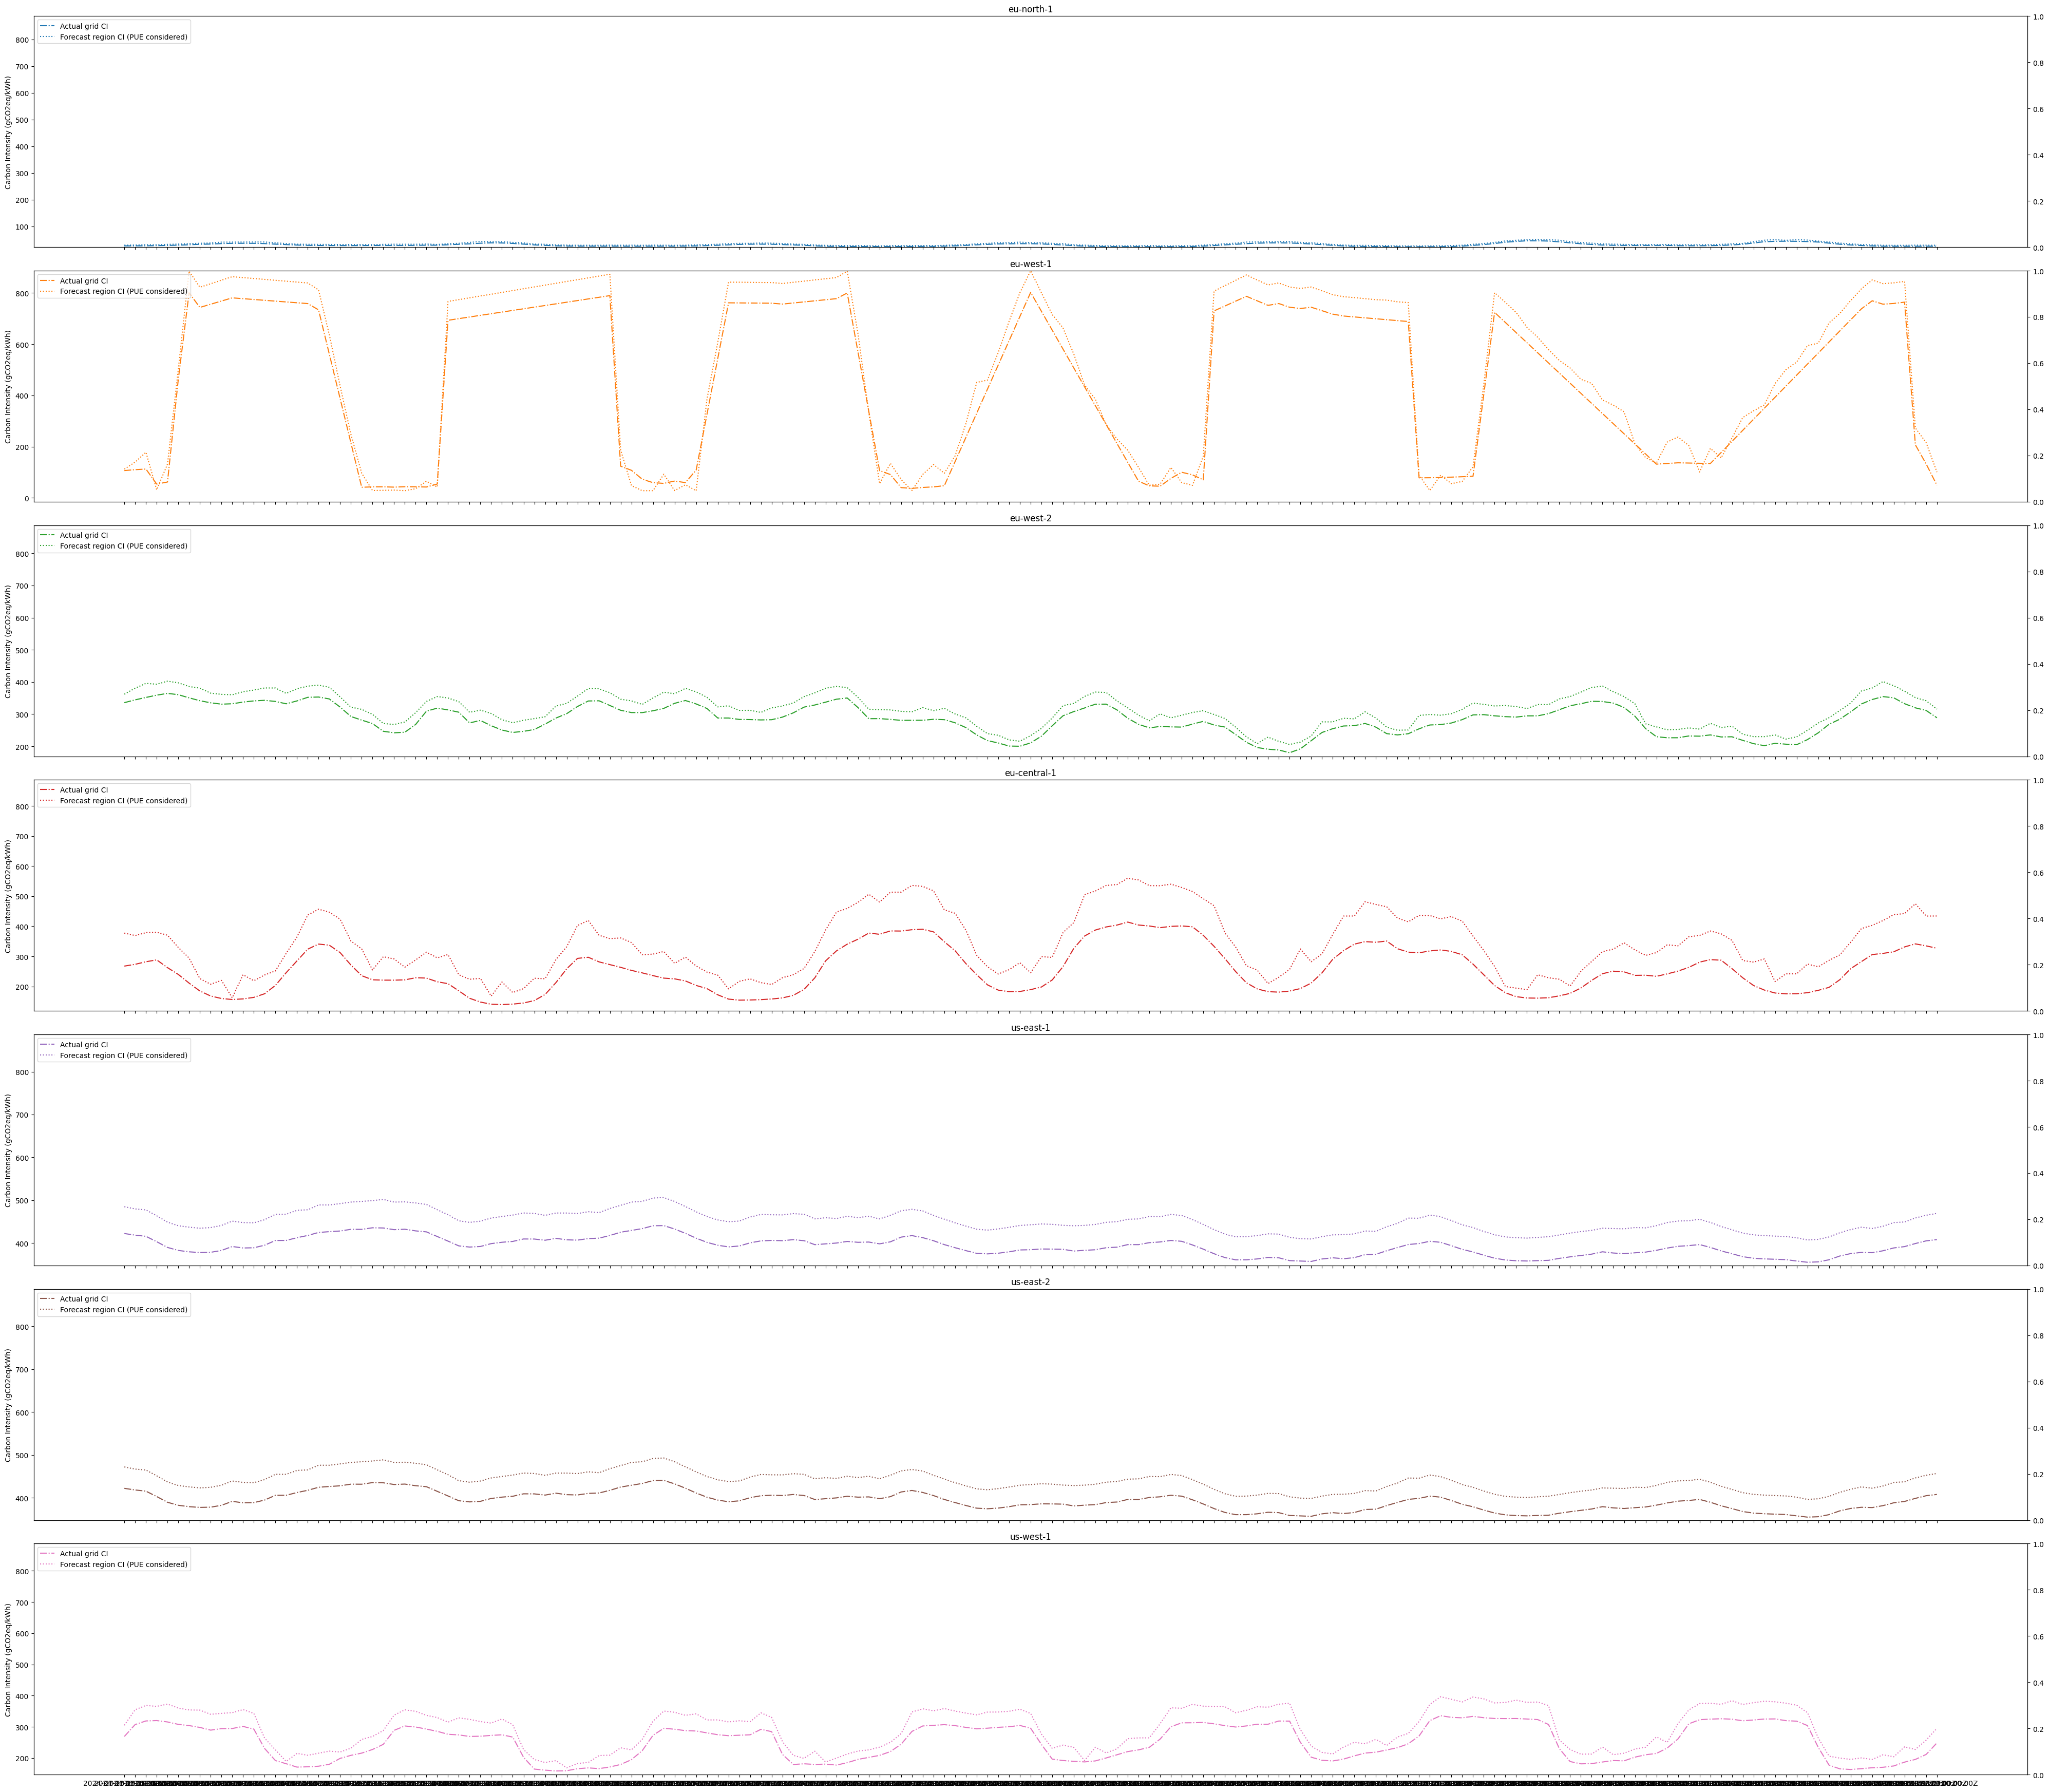

In [7]:


import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(regions), 1, figsize=(40, 5 * len(regions)), sharex=True)
if len(regions) == 1:
    axes = [axes]

for idx, region in enumerate(regions):
    ax = axes[idx]
    ax2 = ax.twinx()
    color = plt.cm.tab10(idx % 10)
    ax.plot(x[region], y_CI[region], label="Actual grid CI", color=color, linestyle="-.")
    ax.plot(x[region], y_CI_comp[region], label="Forecast region CI (PUE considered)", linestyle=":", color=color)
    ax.set_ylabel("Carbon Intensity (gCO2eq/kWh)")
    ax.set_title(region)
    ax.legend(loc="upper left")
    
    
# Set the same y-axis max for all carbon intensity axes
ymax = max(max(y_CI[region] + y_CI_comp[region]) for region in regions)
for ax in axes:
    ax.set_ylim(top=ymax)


plt.xlabel("Time")
plt.tight_layout()
plt.show()

In [ ]:
dfs.groupby(["region", "timestamp"]).sum()

y_power, y_power_baseline = {}, {}
for region in regions:
    series = dfs[dfs["region"] == region].groupby("timestamp").sum()["energy_kwh"]
    series_baseline = dfs_baseline[dfs_baseline["region"] == region].groupby("timestamp").sum()["energy_kwh"]
    y_power[region] = []
    y_power_baseline[region] = []
    for t in x[region]:
        if t in series.index:
            y_power[region].append(series[t])
        else: 
            y_power[region].append(0)
        if t in series_baseline.index:
            y_power_baseline[region].append(series_baseline[t])
        else:
            y_power_baseline[region].append(0)


In [ ]:


import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(regions), 1, figsize=(40, 5 * len(regions)), sharex=True)
if len(regions) == 1:
    axes = [axes]

for idx, region in enumerate(regions):
    ax = axes[idx]
    ax2 = ax.twinx()
    color = plt.cm.tab10(idx % 10)
    ax.plot(x[region], y_CI[region], label="Actual grid CI", color=color, linestyle="-.")
    ax.plot(x[region], y_CI_comp[region], label="Forecast region CI (PUE considered)", linestyle=":", color=color)
    ax2.plot(x[region], y_power[region], label="Power", linestyle="-", color=color)
    ax2.plot(x[region], y_power_baseline[region], label="Power Baseline", linestyle="-", color="gray", alpha=0.5)
    ax.set_ylabel("Carbon Intensity (gCO2eq/kWh)")
    ax2.set_ylabel("Energy (kWh)")
    ax.set_title(region)
    ax.legend(loc="upper left")
    ax2.legend(loc="upper right")
    ax.set_yscale("log")
    ax2.set_yscale("log")

    
# Set the same y-axis max for all carbon intensity axes
ymax = max(max(y_CI[region] + y_CI_comp[region]) for region in regions)
for ax in axes:
    ax.set_ylim(top=ymax)


plt.xlabel("Time")
plt.tight_layout()
plt.show()

In [ ]:

fig, ax = plt.subplots(figsize=(20, 5))
for region in regions:  
    ax2 = ax.twinx()
    color = plt.cm.tab10(regions.index(region) % 10)
    ax2.plot(x[region], y_power[region], label=f"{region} - R", linestyle="-.", color=color)
    ax.plot(x[region], y_CI_comp[region], label=f"{region} - L", linestyle=":", color=color)
ax.set_ylabel("Power (kWh)")
ax.set_title(region)
ax.legend()
 